# CS415 Lab 2: Convnets & LSTMs

## Part 1: Transfer Learning with ConvNet Architectures
In this part, we will explore how to use models pretrained on ImageNet for a new, smaller task: classifying CIFAR-10.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18, mobilenet_v2, efficientnet_b0, convnext_tiny
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd

# Set device (GPU if available, else CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### 1.2 Data Preparation (CIFAR-10)
Pretrained models expect inputs of size 224x224 and specific normalization. We must transform CIFAR-10's 32x32 images. Define transformations to the train dataset that:


*   Resizes inputs to 224x224
*   Applies a random resized crop of size 224
*   Applies a random horizontal flip
*   Normalizes the images with mean: [0.485, 0.456, 0.406] and std: [0.229, 0.224, 0.225]
*   Converts images to tensors

For the test dataset, apply the same transformations except random resized crop and random horizontal flip. Instead, apply a centered crop.





In [ ]:
# Normalization stats for ImageNet
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

# Transforms
transform_train = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    normalize
])

transform_test = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    normalize
])

# Download and load CIFAR-10
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                             download=True, transform=transform_train)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                            download=True, transform=transform_test)

BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

100%|██████████| 170M/170M [00:04<00:00, 38.9MB/s]


### 1.3 Helper Functions

These are our helper functions. Please fill in the blanks for train_one_epoch.

In [ ]:
def count_trainable_parameters(model):
    """Counts the number of parameters that require gradients."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def get_model(model_name, num_classes, freeze_mode='none'):
    """
    Loads a pretrained model, freezes layers, and replaces the classifier.

    freeze_mode:
        'none' (full fine-tuning): Unfreeze all layers.
        'linear_probe': Freeze all base layers, only train the new classifier.
        'partial_freeze': Freeze all except the final few blocks.
    """
    model = None

    if model_name == 'resnet18':
        model = resnet18(weights='IMAGENET1K_V1')
    elif model_name == 'mobilenet_v2':
        model = mobilenet_v2(weights='IMAGENET1K_V1')
    elif model_name == 'efficientnet_b0':
        model = efficientnet_b0(weights='IMAGENET1K_V1')
    elif model_name == 'convnext_tiny':
        model = convnext_tiny(weights='IMAGENET1K_V1')
    else:
        raise ValueError(f"Unknown model name: {model_name}")

    # Freeze layers based on mode
    if freeze_mode == 'linear_probe':
        for param in model.parameters():
            param.requires_grad = False
    elif freeze_mode == 'partial_freeze':
        # This is an example; logic can be more complex
        # Freeze all
        for param in model.parameters():
            param.requires_grad = False

        # Unfreeze the last block (e.g., layer4 in ResNet)
        if model_name == 'resnet18':
            for param in model.layer4.parameters():
                param.requires_grad = True
        elif model_name == 'mobilenet_v2':
            for param in model.features[-4:].parameters():
                param.requires_grad = True
        elif model_name == 'efficientnet_b0':
            # EfficientNet has 9 feature blocks (0-8)
            print("Unfreezing: model.features[8]")
            for param in model.features[8].parameters():
                param.requires_grad = True
        elif model_name == 'convnext_tiny':
            # ConvNeXt has 4 main stages (features[2], [3], [4], [5])
            print("Unfreezing: model.features[5]")
            for param in model.features[5].parameters():
                param.requires_grad = True

    # Replace the classifier head
    if model_name == 'resnet18':
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)
    elif model_name in ['mobilenet_v2', 'efficientnet_b0']:
        in_features = model.classifier[-1].in_features
        model.classifier[-1] = nn.Linear(in_features, num_classes)
    elif model_name == 'convnext_tiny':
        in_features = model.classifier[2].in_features
        model.classifier[2] = nn.Linear(in_features, num_classes)

    return model.to(device)

# --- Training and Evaluation Loops ---

def train_one_epoch(model, loader, optimizer, criterion, max_iter=None):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    iter = 0

    for inputs, labels in tqdm(loader, total=max_iter, desc="Training", leave=False):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        iter += 1

        if max_iter is not None and iter >= max_iter:
            break


    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc="Testing", leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

### 1.4 Experiment 1: Freeze the entire feature extractor, train the last layer, using the ResNet-18 backbone.

In [ ]:
print("--- Experiment 1: Linear Probing (ResNet-18) ---")

# 1. Get model and freeze base
model_lp = get_model('resnet18', num_classes=10, freeze_mode='linear_probe')
param_count_lp = count_trainable_parameters(model_lp)
print(f"Trainable Parameters (Linear Probe): {param_count_lp:,}")

# 2. Define optimizer and criterion (use learning rate of 1e-3)
# Note: Only pass the parameters of the new head to the optimizer!
optimizer_lp = optim.Adam(model_lp.fc.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# 3. Train for a few epochs, set the maximum number of iterations as 200
NUM_EPOCHS = 3
for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model_lp, train_loader, optimizer_lp, criterion, max_iter=200)
    test_loss, test_acc = evaluate(model_lp, test_loader, criterion)
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | "
          f"Test Loss: {test_loss:.4f} Acc: {test_acc:.2f}%")

--- Experiment 1: Linear Probing (ResNet-18) ---
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 193MB/s]


Trainable Parameters (Linear Probe): 5,130


Epoch 1/3 | Train Loss: 0.4130 Acc: 44.55% | Test Loss: 1.0242 Acc: 67.52%


Epoch 2/3 | Train Loss: 0.3274 Acc: 55.66% | Test Loss: 0.8786 Acc: 71.61%


Epoch 3/3 | Train Loss: 0.3071 Acc: 58.78% | Test Loss: 0.8229 Acc: 72.69%


### 1.5 Experiment 2: Full Fine-tuning: Unfreeze entire layer, train with a lower learning rate.

In [ ]:
print("\n--- Experiment 2: Full Fine-Tuning (ResNet-18) ---")

# 1. Get model and unfreeze all
model_ft = get_model('resnet18', num_classes=10, freeze_mode='none')
param_count_ft = count_trainable_parameters(model_ft)
print(f"Trainable Parameters (Full Fine-Tune): {param_count_ft:,}")

# 2. Define optimizer (passes all parameters), use a smaller learning rate, e.g 1e-4. Use cross entropy loss again
optimizer_ft = optim.Adam(model_ft.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

# 3. Train with maximum number of iterations set to 200 again
for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model_ft, train_loader, optimizer_ft, criterion, max_iter=200)
    test_loss, test_acc = evaluate(model_ft, test_loader, criterion)
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | "
          f"Test Loss: {test_loss:.4f} Acc: {test_acc:.2f}%")



--- Experiment 2: Full Fine-Tuning (ResNet-18) ---
Trainable Parameters (Full Fine-Tune): 11,181,642


Epoch 1/3 | Train Loss: 0.2683 Acc: 63.78% | Test Loss: 0.4367 Acc: 85.18%


Epoch 2/3 | Train Loss: 0.1790 Acc: 75.70% | Test Loss: 0.3481 Acc: 87.69%


Epoch 3/3 | Train Loss: 0.1619 Acc: 78.46% | Test Loss: 0.3089 Acc: 89.28%


### 1.6 Compare different architectures with the fine-tuning setup

In [ ]:
architectures = ['resnet18', 'mobilenet_v2', 'efficientnet_b0', 'convnext_tiny']
results = []
NUM_EPOCHS = 3

for arch in architectures:
    print(f"\n--- Training {arch} (Full Fine-Tune) ---")
    model = get_model(arch, num_classes=10, freeze_mode='none')
    param_count = count_trainable_parameters(model)
    print(f"Trainable Parameters: {param_count:,}")

    # Same parameters as the previous finetuning setup
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.CrossEntropyLoss()

    best_acc = 0
    for epoch in range(NUM_EPOCHS):
        # Let's make number of iterations 100 this time to complete faster
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, max_iter=100)
        test_loss, test_acc = evaluate(model, test_loader, criterion)
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Test Acc: {test_acc:.2f}%")
        if test_acc > best_acc:
            best_acc = test_acc

    results.append({'Architecture': arch, 'Trainable Params': param_count, 'Test Accuracy': best_acc})

# Display results
results_df = pd.DataFrame(results)
print("\n--- Architecture Comparison ---")
print(results_df.to_markdown(index=False))


--- Training resnet18 (Full Fine-Tune) ---
Trainable Parameters: 11,181,642


Epoch 1/3 | Test Acc: 76.58%


Epoch 2/3 | Test Acc: 85.30%


Epoch 3/3 | Test Acc: 86.73%

--- Training mobilenet_v2 (Full Fine-Tune) ---
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 156MB/s]


...

100%|██████████| 109M/109M [00:00<00:00, 191MB/s] 


Trainable Parameters: 27,827,818


Epoch 1/3 | Test Acc: 92.28%


Epoch 2/3 | Test Acc: 94.37%


Epoch 3/3 | Test Acc: 95.11%

--- Architecture Comparison ---
| Architecture    |   Trainable Params |   Test Accuracy |
|:----------------|-------------------:|----------------:|
| resnet18        |           11181642 |           86.73 |
| mobilenet_v2    |            2236682 |           85.09 |
| efficientnet_b0 |            4020358 |           88.69 |
| convnext_tiny   |           27827818 |           95.11 |


##Part 2: CNN + LSTM Network for Image Captioning

## 2.1 Codebase for the network: We define three classes:


*   **Vocabulary**: This will be our text generator's vocabulary. It will be using the words in dataset's captions to create its own captions.
*   **FlickrDataset**: This is the custom dataset class we will be using for the subset of Flickr8k that we have created beforehand.
*   **MyCollate**: This will be used to pad the captions so that we can input all of them to the same sequence model.



In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
import spacy # For text tokenization
from collections import Counter

# --- 1. Build a Vocabulary ---
# This class is essential for mapping words to indices
class Vocabulary:
    """
    Manages the mapping between words and numerical indices.
    """
    def __init__(self, freq_threshold):
        # 0:PAD, 1:START, 2:END, 3:UNK
        self.itos = {0: "<PAD>", 1: "<START>", 2: "<END>", 3: "<UNK>"}
        self.stoi = {"<PAD>": 0, "<START>": 1, "<END>": 2, "<UNK>": 3}
        self.freq_threshold = freq_threshold
        self.nlp = spacy.load("en_core_web_sm")

    def __len__(self):
        return len(self.itos)

    def tokenizer(self, text):
        """Basic tokenizer using spacy"""
        return [tok.text.lower() for tok in self.nlp.tokenizer(text) if not tok.is_punct]

    def build_vocabulary(self, sentence_list):
        """Builds the vocabulary from a list of training captions"""
        frequencies = Counter()
        idx = 4 # Start after PAD, START, END, UNK

        print(f"Building vocabulary from {len(sentence_list)} sentences...")
        for sentence in sentence_list:
            for word in self.tokenizer(sentence):
                frequencies[word] += 1

                # Add word to vocab if it reaches the threshold
                if frequencies[word] == self.freq_threshold:
                    self.stoi[word] = idx
                    self.itos[idx] = word
                    idx += 1
        print(f"Built vocabulary with {len(self.itos)} words.")

    def numericalize(self, text):
        """Converts a text string to a list of indices"""
        tokenized_text = self.tokenizer(text)
        return [self.stoi.get(word, self.stoi["<UNK>"]) for word in tokenized_text]

# --- 2. Create a Custom Dataset ---

class FlickrDataset(Dataset):
    """
    Custom Dataset class for our preprocessed Flickr8k subset.
    """
    def __init__(self, root_dir, df, vocab, transform):
        self.root_dir = root_dir
        self.df = df
        self.vocab = vocab
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]
        img_name = row['image_name']
        img_path = os.path.join(self.root_dir, img_name)

        # Load image
        try:
            image = Image.open(img_path).convert("RGB")
            if self.transform:
                image = self.transform(image)
        except FileNotFoundError:
            print(f"Warning: Image not found {img_path}")
            # Return a blank tensor if image is missing
            return torch.zeros((3, 224, 224)), torch.tensor([0])

        # Numericalize caption
        caption = row['caption']
        numericalized_caption = [self.vocab.stoi["<START>"]]
        numericalized_caption.extend(self.vocab.numericalize(caption))
        numericalized_caption.append(self.vocab.stoi["<END>"])

        return image, torch.tensor(numericalized_caption)

# --- 3. Create a custom collate_fn for padding ---
# We need this because captions have different lengths

class MyCollate:
    """
    A custom collate_fn to pad sequences to the same length in a batch.
    """
    def __init__(self, pad_idx):
        self.pad_idx = pad_idx

    def __call__(self, batch):
        # Separate images and captions
        imgs = [item[0].unsqueeze(0) for item in batch]
        imgs = torch.cat(imgs, dim=0)

        # Get captions, pad them
        targets = [item[1] for item in batch]
        targets = nn.utils.rnn.pad_sequence(targets, batch_first=True, padding_value=self.pad_idx)

        return imgs, targets

## 2.2 Architecture

We will be using a CNN as the feature extractor (encoder), and an LSTM as the decoder. The LSTM model will be predicting the next word given the input (previously the image features), and we will update the input and get the next token iteratively (like how any generation model works).

1. Define a frozen encoder that uses a pretrained ResNet50, remove its classifier head and add a Linear layer + ReLU that outputs the features of length (batch size, embedding size). Then, define the forward function accordingly.
2. Define a decoder LSTM network that takes the features and captions, and outputs a caption that we will train to be close to the ground truth. To do that, we will first get the word embeddings from the caption using an Embedding layer, feed it to an LSTM network together with the image features and add a linear layer that will predict the output sequence.
3. Lastly, define a ImageCaptioner module that uses the encoder and decoder, and define a forward method for the training, and a generate_caption method to get an output from the network for a specific image.

In [ ]:
class EncoderCNN(nn.Module):
    def __init__(self, embed_size):
        super(EncoderCNN, self).__init__()
        # Use a pretrained ResNet, but remove the final FC layer
        resnet = models.resnet50(weights='IMAGENET1K_V1')
        for param in resnet.parameters():
            param.requires_grad_(False) # Freeze the encoder

        modules = list(resnet.children())[:-1] # Remove classifier
        self.resnet = nn.Sequential(*modules)
        self.fc = nn.Linear(resnet.fc.in_features, embed_size)
        self.relu = nn.ReLU()

    def forward(self, images):
        features = self.resnet(images) # (batch, 2048, 1, 1)
        features = features.view(features.size(0), -1) # output will be (batch, 2048)
        features = self.relu(self.fc(features)) # output will be (batch, embed_size)
        return features

class DecoderLSTM(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers=1):
        super(DecoderLSTM, self).__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)               # Turn the word ID into word embeddings (vector representation of the word) (vocab size, embed size)
        self.lstm = nn.LSTM(embed_size, hidden_size, num_layers, batch_first=True)                # LSTM layer
        self.fc = nn.Linear(hidden_size, vocab_size)                  # Linear layer

    def forward(self, features, captions):
        # Don't feed the <END> token to the LSTM
        captions = captions[:, :-1]
        caption_embeddings = self.embed(captions) # (batch, seq_len, embed_size)

        # Concat image features and caption embeddings
        # The image feature acts as the "first word"
        features = features.unsqueeze(1) # (batch, 1, embed_size)
        inputs = torch.cat((features, caption_embeddings), dim=1) # (batch, seq_len + 1, embed_size)

        lstm_out, _ = self.lstm(inputs)
        outputs = self.fc(lstm_out)
        return outputs

class ImageCaptioner(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers=1):
        super(ImageCaptioner, self).__init__()
        self.encoder = EncoderCNN(embed_size)
        self.decoder = DecoderLSTM(embed_size, hidden_size, vocab_size, num_layers)

    def forward(self, images, captions):
        features = self.encoder(images)
        outputs = self.decoder(features, captions)
        return outputs

    def generate_caption(self, image, vocab, max_length=50):
        """
        Generates a caption for a single image during inference.
        """
        self.eval()
        with torch.no_grad():
            image_tensor = image.unsqueeze(0) # Add batch dim
            features = self.encoder(image_tensor) # (1, embed_size)

            # Start generating caption
            generated_caption = []

            # Initialize hidden state for LSTM (or just use features as first input)
            # We'll use the logic from the Decoder's forward pass

            # Start with <START> token
            inputs = features.unsqueeze(1) # the next token to process (1, 1, embed_size)
            states = None                  # our memory for the lstm

            for _ in range(max_length):
                lstm_out, states = self.decoder.lstm(inputs, states) # (1, 1, hidden_size)
                outputs = self.decoder.fc(lstm_out.squeeze(1)) # (1, vocab_size)
                predicted_idx = outputs.argmax(1) # (1)

                word_idx = predicted_idx.item()
                # Append the word index to the generated caption
                generated_caption.append(word_idx)

                # Stop if <END> token is generated
                if word_idx == vocab.stoi["<END>"]:
                    break

                # Prepare next input
                inputs = self.decoder.embed(predicted_idx).unsqueeze(1) # (1, 1, embed_size)

        self.train()
        # Convert indices back to words
        return [vocab.itos[idx] for idx in generated_caption]

Define the datasets and dataloaders.

In [ ]:
def get_data_loaders(root_dir, train_csv, test_csv, batch_size=32):
    """
    This is the main script to build the vocab and create the DataLoaders.
    """
    # 1. Load CSVs
    try:
        train_df = pd.read_csv(train_csv)
        test_df = pd.read_csv(test_csv)
    except FileNotFoundError as e:
        print(f"Error: {e}")
        print("Please make sure 'train_captions.csv' and 'test_captions.csv' are in the root directory.")
        return None, None, None

    # 2. Build Vocabulary
    # Use a small freq_threshold since our dataset is small
    vocab = Vocabulary(freq_threshold=2)
    vocab.build_vocabulary(train_df['caption'].tolist())

    # 3. Define image transforms (for ImageNet pretrained models)
    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.CenterCrop((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])

    # 4. Create Dataset instances
    train_dataset = FlickrDataset(
        root_dir=root_dir,
        df=train_df,
        vocab=vocab,
        transform=transform
    )

    test_dataset = FlickrDataset(
        root_dir=root_dir,
        df=test_df,
        vocab=vocab,
        transform=transform
    )

    # 5. Define Collate function for padding
    pad_idx = vocab.stoi["<PAD>"]
    collate_fn = MyCollate(pad_idx=pad_idx)

    # 6. Create DataLoaders
    train_loader = DataLoader(
        dataset=train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        collate_fn=collate_fn
    )

    test_loader = DataLoader(
        dataset=test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        collate_fn=collate_fn
    )

    return train_loader, test_loader, vocab

## 2.3 Main training script:

Fill in the blanks to train our network.

Image directory 'content' already exists or zip file not found.
Loading data...
Building vocabulary from 4000 sentences...
Built vocabulary with 1628 words.
Initializing model...
--- Starting Training on cuda ---


Epoch 1/7: 100%|██████████| 125/125 [00:23<00:00,  5.41it/s, loss=4.25]


Epoch 1/7, Loss: 4.7639


Epoch 2/7: 100%|██████████| 125/125 [00:25<00:00,  4.93it/s, loss=4.3]


Epoch 2/7, Loss: 4.1776


...

Epoch 5/7, Loss: 3.5477


Epoch 6/7: 100%|██████████| 125/125 [00:23<00:00,  5.21it/s, loss=3.38]


Epoch 6/7, Loss: 3.3683


Epoch 7/7: 100%|██████████| 125/125 [00:24<00:00,  5.19it/s, loss=3.31]


Epoch 7/7, Loss: 3.1711
--- Training Complete ---

--- Testing Model on a Sample ---
Actual Caption:    a group of eight people are gathered around a table at night
Predicted Caption: a <UNK> a


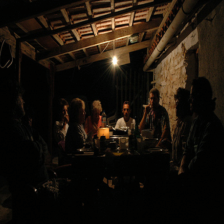

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from PIL import Image
import os
import spacy
from collections import Counter
import zipfile
from tqdm import tqdm

zip_path = 'images_subset.zip'
extract_dir = 'content'

if os.path.exists(zip_path) and not os.path.exists(extract_dir):
    print(f"Unzipping {zip_path}...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('.')
    print(f"Unzipped images to '{extract_dir}'")
else:
    print(f"Image directory '{extract_dir}' already exists or zip file not found.")

IMAGE_DIR = extract_dir + "/Images_Subset_1k"
TRAIN_CSV = 'train_captions.csv'
TEST_CSV = 'test_captions.csv'
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def main_training():
    """
    Main script to run the full training and testing pipeline.
    """

    # --- Load Data ---
    print("Loading data...")
    train_loader, test_loader, vocab = get_data_loaders(
        root_dir=IMAGE_DIR,
        train_csv=TRAIN_CSV,
        test_csv=TEST_CSV,
        batch_size=32
    )

    if train_loader is None:
        return # Stop if data loading failed

    # --- Initialize Model, Optimizer, Loss ---
    print("Initializing model...")
    # Hyperparameters
    EMBED_SIZE = 256
    HIDDEN_SIZE = 512
    VOCAB_SIZE = len(vocab)
    NUM_LAYERS = 1
    LEARNING_RATE = 1e-3
    NUM_EPOCHS = 7  # This should be higher normally

    # Get components
    model = ImageCaptioner(EMBED_SIZE, HIDDEN_SIZE, VOCAB_SIZE, NUM_LAYERS).to(DEVICE)
    criterion = nn.CrossEntropyLoss(ignore_index=vocab.stoi["<PAD>"])
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # --- Training Loop ---
    print(f"--- Starting Training on {DEVICE} ---")

    for epoch in range(NUM_EPOCHS):
        model.train()
        running_loss = 0.0

        # Use tqdm for a nice progress bar
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}", leave=True)

        for images, captions in pbar:
            images, captions = images.to(DEVICE), captions.to(DEVICE)

            # Forward pass
            outputs = model(images, captions)

            # Calculate loss
            # We must reshape outputs and captions for CrossEntropyLoss
            # outputs: (batch, seq_len, vocab_size) -> (batch*seq_len, vocab_size)
            # captions: (batch, seq_len+1) -> targets: (batch, seq_len) -> (batch*seq_len)
            loss = criterion(
                outputs[:, :-1, :].reshape(-1, VOCAB_SIZE),
                captions[:, 1:].reshape(-1) # Use captions[1:] as target
            )

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            pbar.set_postfix({"loss": loss.item()})

        epoch_loss = running_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{NUM_EPOCHS}, Loss: {epoch_loss:.4f}")

    print("--- Training Complete ---")

    # --- 6d. Test the model ---
    print("\n--- Testing Model on a Sample ---")

    # Get a sample from the test set
    test_img, test_caption_tensor = test_loader.dataset[5] # Get 6th item
    test_img = test_img.to(DEVICE)
    # Generate a caption
    predicted_caption = model.generate_caption(test_img, vocab)
    # Model outputs a list, convert it to a string
    predicted_caption = " ".join(predicted_caption[:-1])

    # Format the actual caption
    actual_caption_indices = [idx.item() for idx in test_caption_tensor
                              if idx.item() not in [vocab.stoi["<START>"], vocab.stoi["<END>"], vocab.stoi["<PAD>"]]]
    actual_caption = " ".join([vocab.itos[idx] for idx in actual_caption_indices])

    print(f"Actual Caption:    {actual_caption}")
    print(f"Predicted Caption: {predicted_caption}")

    # Display the image (if in a notebook)
    try:
        from IPython.display import display
        # We need to un-normalize the image for display
        inv_normalize = transforms.Normalize(
            mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
            std=[1/0.229, 1/0.224, 1/0.225]
        )
        img_display = inv_normalize(test_img)
        display(transforms.ToPILImage()(img_display))
    except ImportError:
        print("(Install IPython to display the test image in the notebook)")

main_training()